In [1]:
# --- [CELL 0]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 1}
import numpy as np
import pandas as pd
import os, datetime, sys, random, time
 
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
 
plt.style.use('fivethirtyeight')
%matplotlib inline
 
from scipy import stats, special
import shap                # 
 
import warnings
warnings.filterwarnings('ignore')
 
train_data=pd.read_csv("data/cs-training_synthetic.csv",encoding="utf-8")
test_data=pd.read_csv("data/cs-test_synthetic.csv",encoding="utf-8")
 
print(train_data.head())
print(test_data.head())

   Unnamed: 0  SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  age  \
0       67049                 0                              13065.01    4   
1       84763                 1                              42503.32   93   
2       33689                 0                              46558.48   64   
3      120440                 0                               5000.79   24   
4       15935                 0                              13460.01   80   

   NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  MonthlyIncome  \
0                                    79   57166.21      269520.07   
1                                    84  268195.28      420841.21   
2                                    91   44918.82     2759862.65   
3                                     2  219641.71      475124.23   
4                                    75   36959.79      666643.74   

   NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  \
0                               54                   

In [2]:
# --- [CELL 1]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 2}
# remove id 
dev_train=train_data.drop("Unnamed: 0",axis=1)
# 测试集也做同样操作
print(test_data.info())
dev_test=test_data.drop("Unnamed: 0",axis=1)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101503 entries, 0 to 101502
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            101503 non-null  int64  
 1   SeriousDlqin2yrs                      0 non-null       float64
 2   RevolvingUtilizationOfUnsecuredLines  101503 non-null  float64
 3   age                                   101503 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  101503 non-null  int64  
 5   DebtRatio                             101503 non-null  float64
 6   MonthlyIncome                         81400 non-null   float64
 7   NumberOfOpenCreditLinesAndLoans       101503 non-null  int64  
 8   NumberOfTimes90DaysLate               101503 non-null  int64  
 9   NumberRealEstateLoansOrLines          101503 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  101503 non-null  int64  
 11  

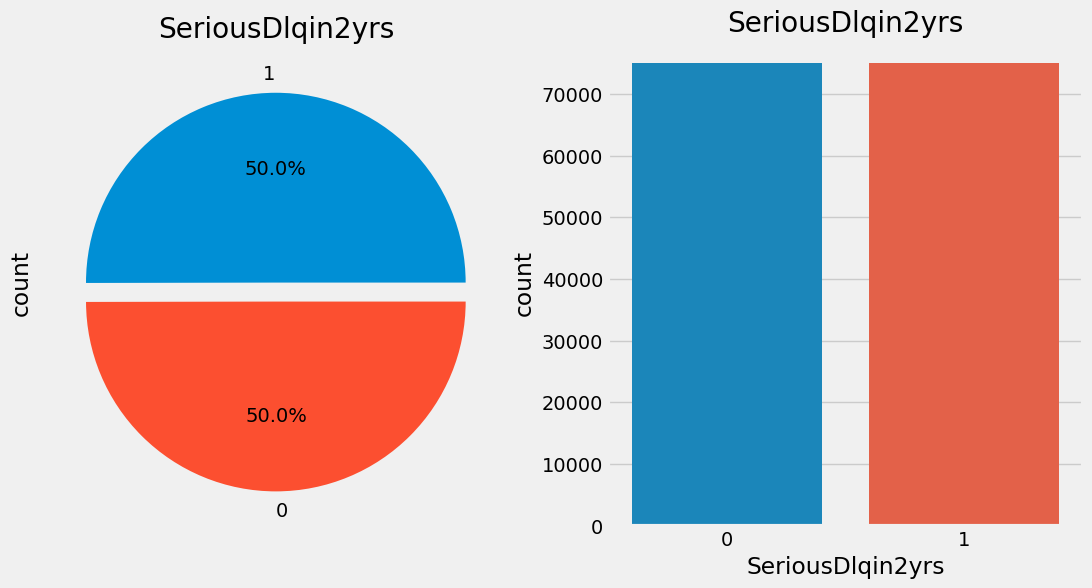

In [3]:
# --- [CELL 2]: ---
# cell_state: edited
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 3}
# === BEFORE (original) ===
# import seaborn as sns
# # 检查数据正负样本是否平衡
# fig,axes=plt.subplots(1,2,figsize=(12,6))
# # pandas自带绘图
# dev_train['SeriousDlqin2yrs'].value_counts().plot.pie(explode=[0,0.1],autopct="%1.1f%%",ax=axes[0])
# axes[0].set_title("SeriousDlqin2yrs")
# sns.countplot("SeriousDlqin2yrs",data=dev_train,ax=axes[1])
# axes[1].set_title("SeriousDlqin2yrs")
# plt.show()

# === AFTER (edited) ===
import seaborn as sns

fig,axes=plt.subplots(1,2,figsize=(12,6))

dev_train['SeriousDlqin2yrs'].value_counts().plot.pie(explode=[0,0.1],autopct="%1.1f%%",ax=axes[0])
axes[0].set_title("SeriousDlqin2yrs")
sns.countplot(x="SeriousDlqin2yrs",data=dev_train,ax=axes[1])
axes[1].set_title("SeriousDlqin2yrs")
plt.show()